## Laborator 6  -  Rezolvarea unor probleme de regresie prin metode de învățare automată

#### 💡 Probleme
Ce îi poate face pe oameni fericiți? Se consideră problema predicției gradului de fericire a populației globului folosind informații despre diferite caracteristici a bunăstării respectivei populații precum Produsul intern brut al țării în care locuiesc (gross domestic product – GBP), gradul de fericire, etc.

Folosind datele aferente anului 2017, să se realizeze o predicție a gradului de fericire în funcție:

* doar de Produsul intern brut
* de Produsul intern brut si de gradul de libertate.


#### 📝 Cerinte
Specificaţi, proiectaţi, implementaţi si testati cate un algoritm de regresie pentru prima problema bazat pe:

metoda gradientului descrescator bazat pe batch-uri, cu tool/API si/sau cod propriu (tema).


###### 🏵️ Cerinte opționale

Rezolvarea unei probleme de regresie/clasificare prin:

folosirea validarii încrucișate
investigarea diferitelor funcții de loss
ce se întîmplă în cazul clasificarii binare daca se modifică pragul de decizie din 0.5 în alte valori. Cum se poate aprecia calitatea clasificatorului pentru diferite valori ale pragului?

### Gradient descrescător pe batch-uri:

*  folosind tool/API (ex: scikit-learn, Tensorflow, etc.)
* cod propriu


Batch Gradient Descent = folosești toate datele din setul de antrenament pentru a calcula gradientul și pentru a actualiza parametrii o dată pe epocă.

In [ ]:
import warnings; warnings.simplefilter('ignore')
import csv
import matplotlib.pyplot as plt
import numpy as np


Single-variate regression

-> doar de Produsul intern brut

In [ ]:
def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs

import os

crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
print('in:  ', inputs[:5])
print('out: ', outputs[:5])

in:   [1.616463184, 1.482383013, 1.48063302, 1.564979553, 1.443571925]
out:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


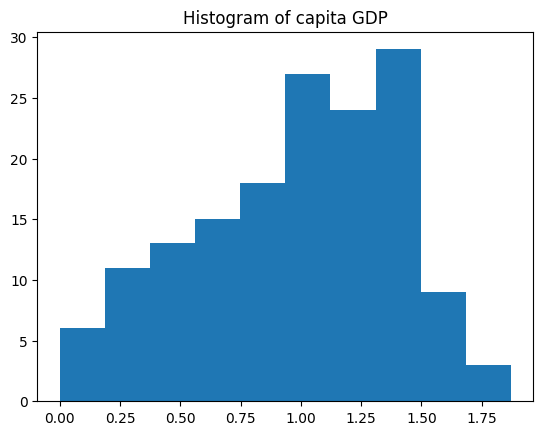

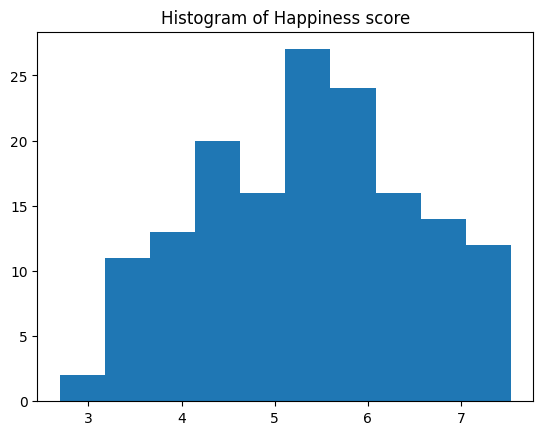

In [ ]:
# see how the data looks (plot the histograms associated to input data - GDP feature - and output data - happiness)

def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs, "capita GDP")
plotDataHistogram(outputs, "Happiness score")

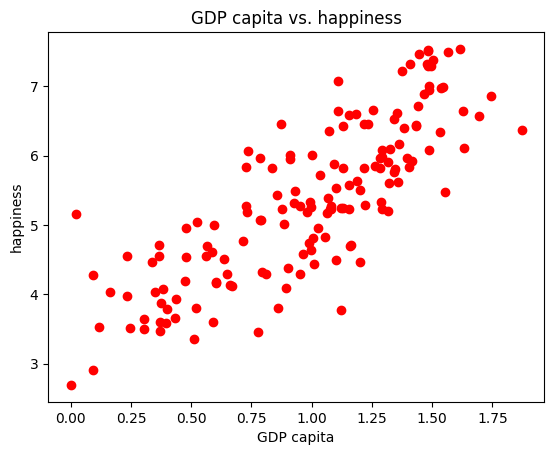

In [ ]:
# check the liniarity (to check that a linear relationship exists between the dependent variable (y = happiness) and the independent variable (x = capita).)

plt.plot(inputs, outputs, 'ro')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.title('GDP capita vs. happiness')
plt.show()

Pasul 2 - impartire date pe train si test

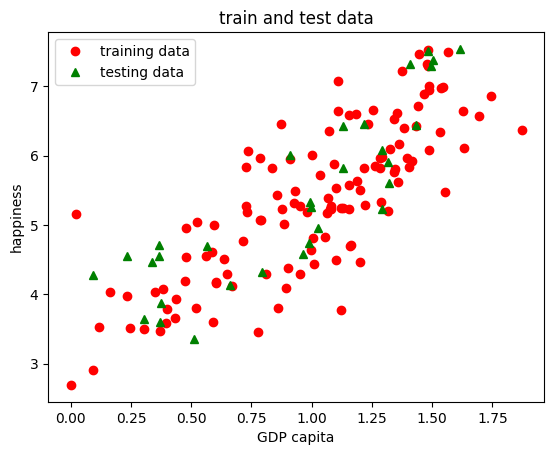

In [ ]:
# Split the Data Into Training and Test Subsets
# In this step we will split our dataset into training and testing subsets (in proportion 80/20%).

# Training data set is used for training the linear model. Testing dataset is used for validating of the model. All data from testing dataset will be new to  model and we may check how accurate are model predictions.

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]

testInputs = [inputs[i] for i in testSample]
testOutputs = [outputs[i] for i in testSample]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')   #train data are plotted by red and circle sign
plt.plot(testInputs, testOutputs, 'g^', label = 'testing data')     #test data are plotted by green and a triangle sign
plt.title('train and test data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

Pasul 3 - invatare model (cu tool sau cod propriu)

In [ ]:
import random

class MySGDRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    # simple stochastic GD
    def fit(self, x, y, learningRate = 0.001, noEpochs = 1000):
        self.coef_ = [0.0 for _ in range(len(x[0]) + 1)]    #beta or w coefficients y = w0 + w1 * x1 + w2 * x2 + ...
        # self.coef_ = [random.random() for _ in range(len(x[0]) + 1)]    #beta or w coefficients
        for epoch in range(noEpochs):
            #shuffle the trainind examples in order to prevent cycles
            # combined = list(zip(x, y))
            # random.shuffle(combined)
            # x[:], y[:] = zip(*combined)

            for i in range(len(x)): # for each sample from the training data
                ycomputed = self.eval(x[i])     # estimate the output
                crtError = ycomputed - y[i]     # compute the error for the current sample
                for j in range(0, len(x[0])):   # update the coefficients
                    self.coef_[j] = self.coef_[j] - learningRate * crtError * x[i][j]
                self.coef_[len(x[0])] = self.coef_[len(x[0])] - learningRate * crtError * 1

        self.intercept_ = self.coef_[-1]
        self.coef_ = self.coef_[:-1]

    def eval(self, xi):
        yi = self.coef_[-1]
        for j in range(len(xi)):
            yi += self.coef_[j] * xi[j]
        return yi

    def predict(self, x):
        yComputed = [self.eval(xi) for xi in x]
        return yComputed

In [ ]:
# learning step: init and train a linear regression model y = f(x) = w0 + w1 * x
# Prediction step: used the trained model to estimate the output for a new input


# training data preparation (the sklearn linear model requires as input training data as noSamples x noFeatures array; in the current case, the input must be a matrix of len(trainInputs) lineas and one columns (a single feature is used in this problem))
xx = [[el] for el in trainInputs]

# # using sklearn
# from sklearn import linear_model
# # model initialisation
# regressor = linear_model.SGDRegressor(alpha = 0.01, max_iter = 100)
# # training the model by using the training inputs and known training outputs
# regressor.fit(xx, trainOutputs)
# # save the model parameters
# w0, w1 = regressor.intercept_[0], regressor.coef_[0]
# print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

# using developed code
# model initialisation
regressor = MySGDRegression()
# training the model by using the training inputs and known training outputs
regressor.fit(xx, trainOutputs)
# save the model parameters
w0, w1 = regressor.intercept_, regressor.coef_[0]
print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

the learnt model: f(x) =  3.199428595630372  +  2.1487678366445757  * x


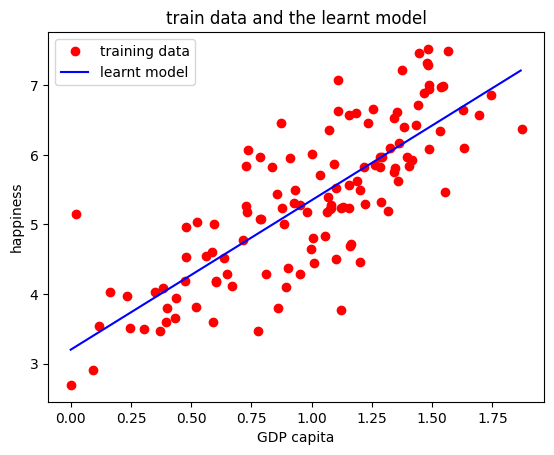

In [ ]:
# plot the learnt model
# prepare some synthetic data (inputs are random, while the outputs are computed by the learnt model)
noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')  #train data are plotted by red and circle sign
plt.plot(xref, yref, 'b-', label = 'learnt model')                  #model is plotted by a blue line
plt.title('train data and the learnt model')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

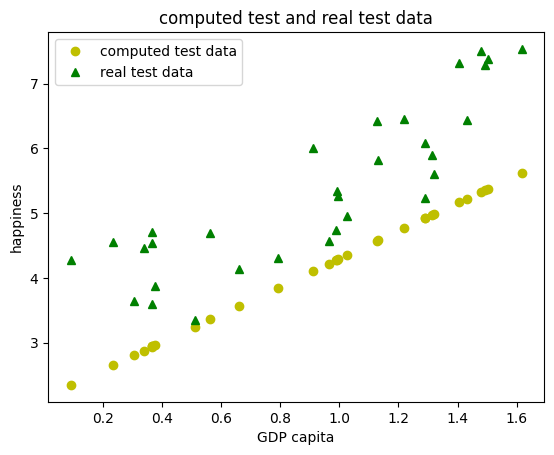

In [ ]:
# use the trained model to predict new inputs

# makes predictions for test data (manual)
# computedTestOutputs = [w0 + w1 * el for el in testInputs]
# makes predictions for test data (by tool)
computedTestOutputs = regressor.predict([[x] for x in testInputs])

# plot the computed outputs (see how far they are from the real outputs)
plt.plot(testInputs, computedTestOutputs, 'yo', label = 'computed test data')  #computed test data are plotted yellow red and circle sign
plt.plot(testInputs, testOutputs, 'g^', label = 'real test data')  #real test data are plotted by green triangles
plt.title('computed test and real test data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

Pasul 5 - calcul metrici de performanta (eroarea)


In [ ]:
#compute the differences between the predictions and real outputs
# "manual" computation
error = 0.0
for t1, t2 in zip(computedTestOutputs, testOutputs):
    error += (t1 - t2) ** 2
error = error / len(testOutputs)
print('prediction error (manual): ', error)

# by using sklearn
from sklearn.metrics import mean_squared_error

error = mean_squared_error(testOutputs, computedTestOutputs)
print('prediction error (tool):  ', error)

prediction error (manual):  1.9008773201978302
prediction error (tool):   1.9008773201978297


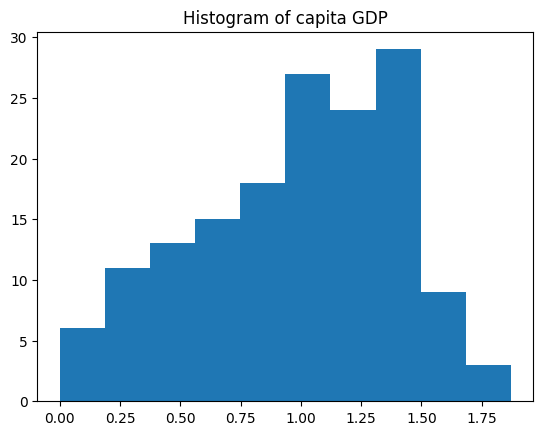

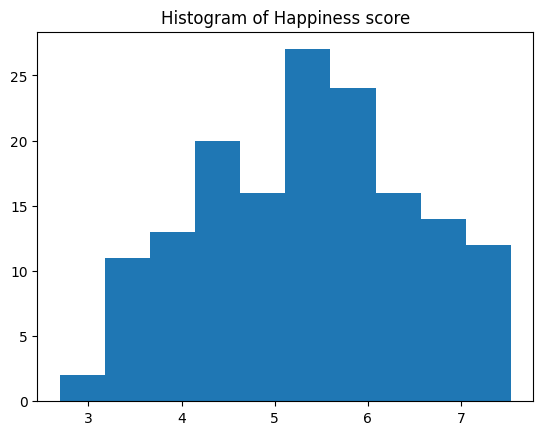

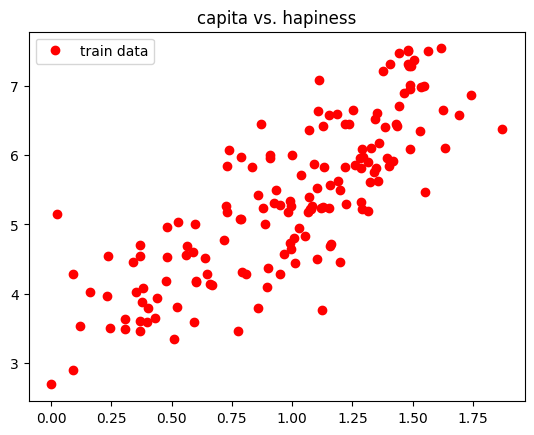

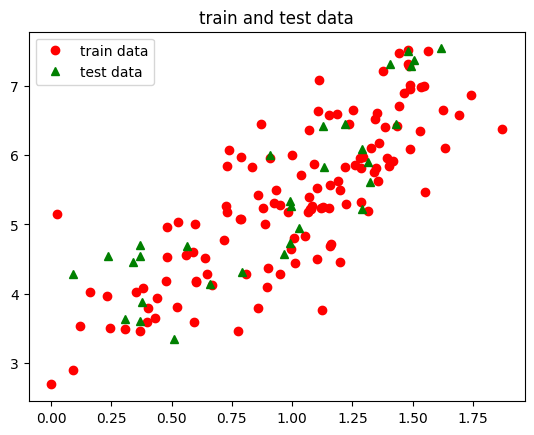

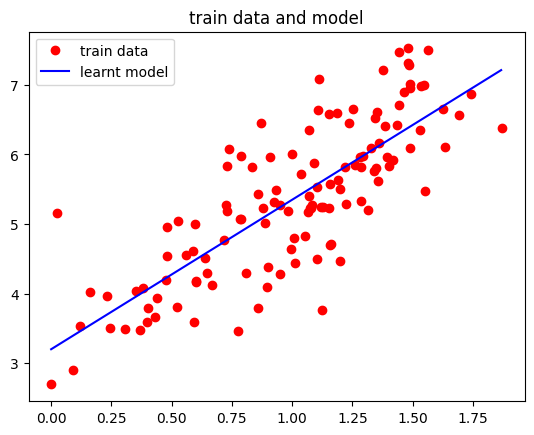

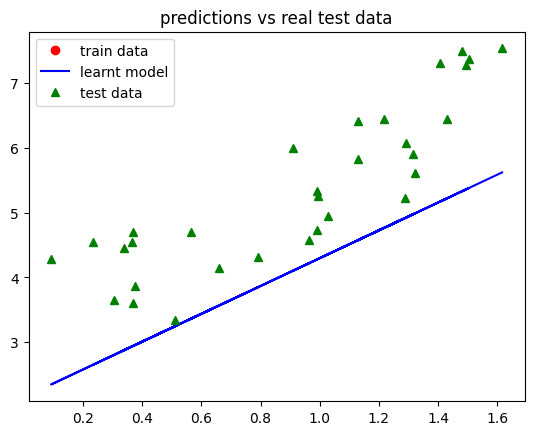

prediction error (manual):  1.9008773201978302
prediction error (tool):  1.9008773201978297


In [ ]:
# put all steps togheter

def plotData(x1, y1, x2 = None, y2 = None, x3 = None, y3 = None, title = None):
    plt.plot(x1, y1, 'ro', label = 'train data')
    if (x2):
        plt.plot(x2, y2, 'b-', label = 'learnt model')
    if (x3):
        plt.plot(x3, y3, 'g^', label = 'test data')
    plt.title(title)
    plt.legend()
    plt.show()

def univariateRegression():
    import os

    crtDir =  os.getcwd()
    filePath = os.path.join(crtDir, 'data', 'world-happiness-report-2017.csv')

    inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')

    plotDataHistogram(inputs, 'capita GDP')
    plotDataHistogram(outputs, 'Happiness score')

    # check the liniarity (to check that a linear relationship exists between the dependent variable (y = happiness) and the independent variable (x = capita).)
    plotData(inputs, outputs, [], [], [], [], 'capita vs. hapiness')

    # split data into training data (80%) and testing data (20%)
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
    testSample = [i for i in indexes  if not i in trainSample]
    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]

    plotData(trainInputs, trainOutputs, [], [], testInputs, testOutputs, "train and test data")

    # training step
    xx = [[el] for el in trainInputs]
    # regressor = linear_model.SGDRegressor(max_iter =  10000)
    regressor = MySGDRegression()
    regressor.fit(xx, trainOutputs)
    w0, w1 = regressor.intercept_, regressor.coef_[0]

    # plot the model
    noOfPoints = 1000
    xref = []
    val = min(trainInputs)
    step = (max(trainInputs) - min(trainInputs)) / noOfPoints
    for i in range(1, noOfPoints):
        xref.append(val)
        val += step
    yref = [w0 + w1 * el for el in xref]
    plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

    #makes predictions for test data
    # computedTestOutputs = [w0 + w1 * el for el in testInputs]
    #makes predictions for test data (by tool)
    computedTestOutputs = regressor.predict([[x] for x in testInputs])
    plotData([], [], testInputs, computedTestOutputs, testInputs, testOutputs, "predictions vs real test data")

    #compute the differences between the predictions and real outputs
    error = 0.0
    for t1, t2 in zip(computedTestOutputs, testOutputs):
        error += (t1 - t2) ** 2
    error = error / len(testOutputs)
    print("prediction error (manual): ", error)

    error = mean_squared_error(testOutputs, computedTestOutputs)
    print("prediction error (tool): ", error)

univariateRegression()

Demo2 - Bi-variate regression


In [ ]:
import csv
import os

from sklearn.preprocessing import StandardScaler
from math import sqrt


def plot3Ddata(x1Train, x2Train, yTrain, x1Model=None, x2Model=None, yModel=None, x1Test=None, x2Test=None, yTest=None, title=None):
    from mpl_toolkits import mplot3d
    fig = plt.figure()  # Create a figure explicitly
    ax = fig.add_subplot(111, projection='3d')  # Add subplot with 3D projection
    if x1Train:
        ax.scatter(x1Train, x2Train, yTrain, c='r', marker='o', label='train data')
    if x1Model:
        ax.scatter(x1Model, x2Model, yModel, c='b', marker='_', label='learnt model')
    if x1Test:
        ax.scatter(x1Test, x2Test, yTest, c='g', marker='^', label='test data')
    plt.title(title)
    ax.set_xlabel("capita")
    ax.set_ylabel("freedom")
    ax.set_zlabel("happiness")
    # Update legend handling to potentially avoid the error
    handles, labels = ax.get_legend_handles_labels()
    if handles:  # Check if handles are available before creating the legend
        ax.legend(handles, labels)
    plt.show()

In [ ]:
def loadDataMoreInputs(fileName, inputVariabNames, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable1 = dataNames.index(inputVariabNames[0])
    selectedVariable2 = dataNames.index(inputVariabNames[1])
    inputs = [[float(data[i][selectedVariable1]), float(data[i][selectedVariable2])] for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs

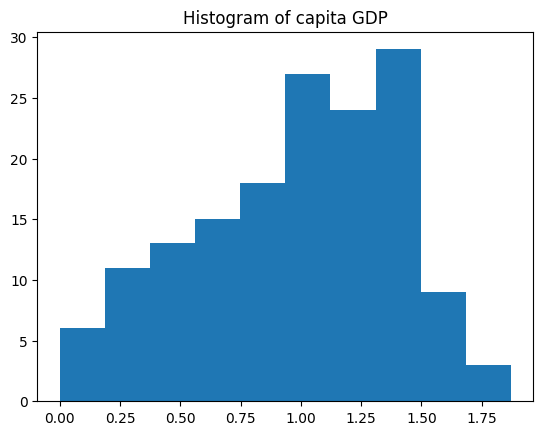

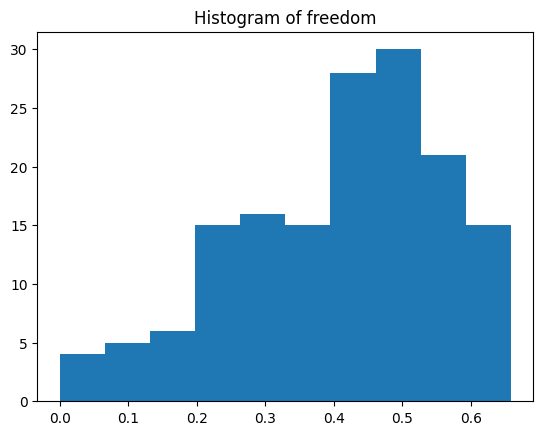

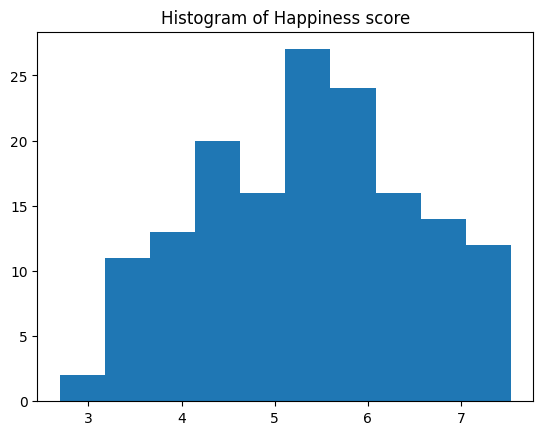

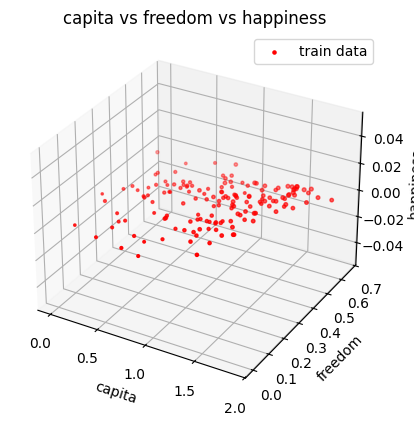

In [ ]:
# problem hapiness = w0 + w1 * GDPcapita + w2 * freedom
# load data
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'world-happiness-report-2017.csv')

inputs, outputs = loadDataMoreInputs(filePath, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')

feature1 = [ex[0] for ex in inputs]
feature2 = [ex[1] for ex in inputs]

# plot the data histograms
plotDataHistogram(feature1, 'capita GDP')
plotDataHistogram(feature2, 'freedom')
plotDataHistogram(outputs, 'Happiness score')

# check the liniarity (to check that a linear relationship exists between the dependent variable (y = happiness) and the independent variables (x1 = capita, x2 = freedom).)
plot3Ddata(feature1, feature2, outputs, [], [], [], [], [], [], 'capita vs freedom vs happiness')

Pasul 2 - impartire date pe train si test si normalizare

In [ ]:
def normalisation(trainData, testData):
    scaler = StandardScaler()
    if not isinstance(trainData[0], list):
        #encode each sample into a list
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]

        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data

        #decode from list to raw values
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data
    return normalisedTrainData, normalisedTestData

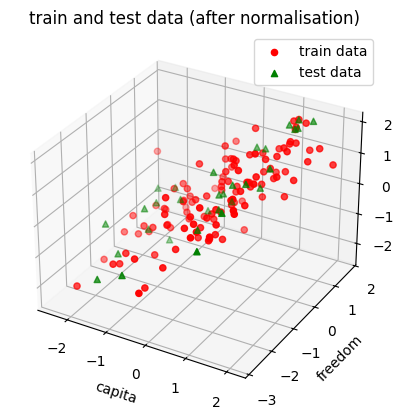

In [ ]:
np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
testInputs = [inputs[i] for i in testSample]
testOutputs = [outputs[i] for i in testSample]


trainInputs, testInputs = normalisation(trainInputs, testInputs)
trainOutputs, testOutputs = normalisation(trainOutputs, testOutputs)

feature1train = [ex[0] for ex in trainInputs]
feature2train = [ex[1] for ex in trainInputs]

feature1test = [ex[0] for ex in testInputs]
feature2test = [ex[1] for ex in testInputs]

plot3Ddata(feature1train, feature2train, trainOutputs, [], [], [], feature1test, feature2test, testOutputs, "train and test data (after normalisation)")

In [ ]:
# identify (by training) the regressor

# # use sklearn regressor
# from sklearn import linear_model
# regressor = linear_model.SGDRegressor()

# using developed code
# model initialisation
regressor = MySGDRegression()

regressor.fit(trainInputs, trainOutputs)
# print(regressor.coef_)
# print(regressor.intercept_)

#parameters of the liniar regressor
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x1 + ', w2, ' * x2' )

the learnt model: f(x) =  -0.001452792456639411  +  0.6978631617868739  * x1 +  0.30375393533970557  * x2


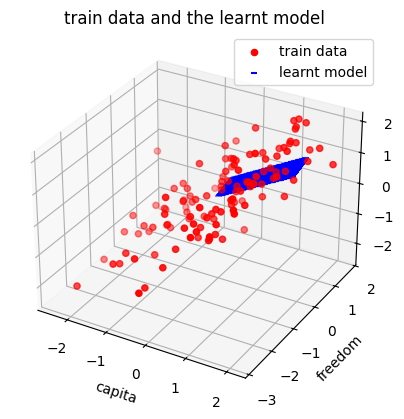

In [ ]:
#numerical representation of the regressor model
noOfPoints = 50
xref1 = []
val = min(feature1)
step1 = (max(feature1) - min(feature1)) / noOfPoints
for _ in range(1, noOfPoints):
    for _ in range(1, noOfPoints):
        xref1.append(val)
    val += step1

xref2 = []
val = min(feature2)
step2 = (max(feature2) - min(feature2)) / noOfPoints
for _ in range(1, noOfPoints):
    aux = val
    for _ in range(1, noOfPoints):
        xref2.append(aux)
        aux += step2
yref = [w0 + w1 * el1 + w2 * el2 for el1, el2 in zip(xref1, xref2)]
plot3Ddata(feature1train, feature2train, trainOutputs, xref1, xref2, yref, [], [], [], 'train data and the learnt model')

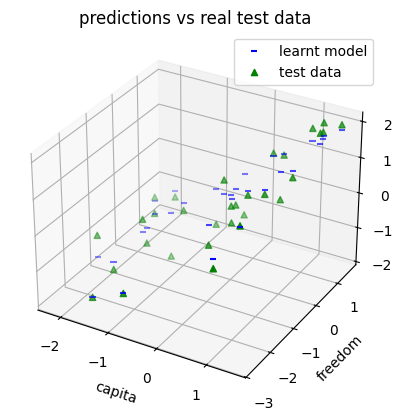

In [ ]:
# use the trained model to predict new inputs

# makes predictions for test data
# computedTestOutputs = [w0 + w1 * el[0] + w2 * el[1] for el in testInputs]
# makes predictions for test data (by tool)
computedTestOutputs = regressor.predict(testInputs)

plot3Ddata([], [], [], feature1test, feature2test, computedTestOutputs, feature1test, feature2test, testOutputs, 'predictions vs real test data')

In [ ]:
#compute the differences between the predictions and real outputs
error = 0.0
for t1, t2 in zip(computedTestOutputs, testOutputs):
    error += (t1 - t2) ** 2
error = error / len(testOutputs)
print('prediction error (manual): ', error)

from sklearn.metrics import mean_squared_error

error = mean_squared_error(testOutputs, computedTestOutputs)
print('prediction error (tool):   ', error)

prediction error (manual):  0.23317939919678513
prediction error (tool):    0.23317939919678513


# TEMA:

Să se rezolve problema, implementându-se rutine pentru:

* gradient descrescător bazat pe batch-uri – cu tool sau cu cod propriu
  * parametrizare a SGDRegressor din sklearn link astfel incat sa efectueze Batch GD
  * implementare proprie a Batch GD
* normalizarea datelor de antrenament și test (cu cod propriu) - implementare proprie pentru normalizarea statistica a datelor din problema de regresie bivariata ( GDP, Freedom si Happiness)

  * Step1: Identificare parametrii normalizare (mean, stdDev) pt setul de train
  * Step2: Normalizarea datelor din train folosind parametrii mean si stdDev (de la pasul 1)
  * Step3: Normalziarea datelor din test folosind parametrii mean si stdDev (de la pasul 1)

In [ ]:
# import necessary libraries
import numpy as np
from sklearn.linear_model import SGDRegressor

# check input dimensions before transformation
print(f"trainInputs dimensions before transformation: {np.array(trainInputs).shape}")

# reshape data to 2D if needed (required for regression models)
trainInputs = np.array(trainInputs)
if trainInputs.ndim == 3:
    trainInputs = trainInputs.reshape(trainInputs.shape[0], -1)

# check input dimensions after transformation
print(f"trainInputs dimensions after transformation: {trainInputs.shape}")

# train the model using SGDRegressor (tool-based batch gradient descent)
regressor = SGDRegressor(max_iter=1000, tol=1e-3, learning_rate='constant', eta0=0.01)
regressor.fit(trainInputs, trainOutputs)

# extract model parameters (intercept and coefficients)
w0 = regressor.intercept_[0]
w1 = regressor.coef_[0]
print(f"learned model: f(x) = {w0} + {w1} * x")

trainInputs dimensions before transformation: (124, 2)
trainInputs dimensions after transformation: (124, 2)
learned model: f(x) = -0.006097780210582734 + 0.7127784160812536 * x


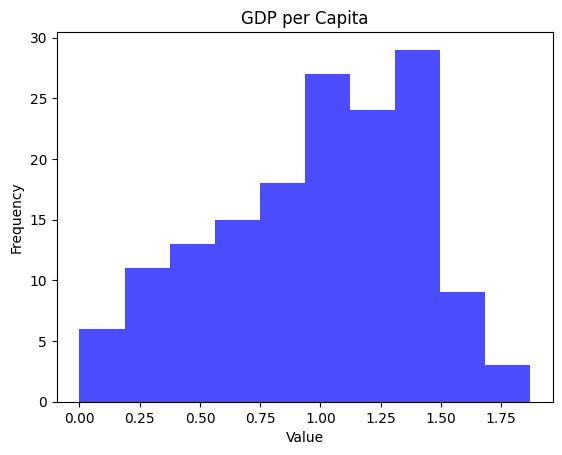

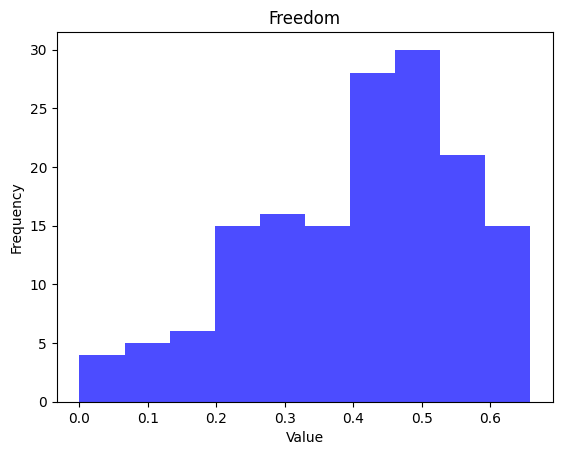

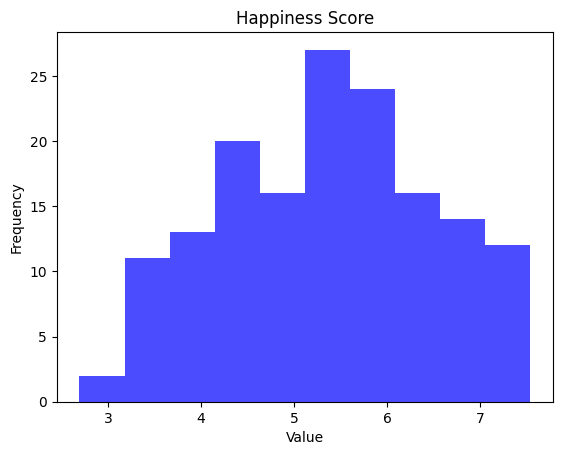

In [ ]:
def plot_histogram(data, title):
    plt.hist(data, bins=10, color='blue', alpha=0.7)
    plt.title(title)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

plot_histogram([x[0] for x in inputs], 'GDP per Capita')
plot_histogram([x[1] for x in inputs], 'Freedom')
plot_histogram(outputs, 'Happiness Score')

In [ ]:
class MyBGDRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    def fit(self, x, y, learningRate = 0.001, noEpochs = 1000):
        n_samples = len(x)
        n_features = len(x[0])
        self.coef_ = [0.0 for _ in range(n_features + 1)]

        for epoch in range(noEpochs):
            gradients = [0.0 for _ in range(n_features + 1)]

            for i in range(n_samples):
                ycomputed = self.eval(x[i])
                error = ycomputed - y[i]
                for j in range(n_features):
                    gradients[j] += error * x[i][j]
                gradients[-1] += error * 1

            # update
            # face update doar dupa ce au fost procesate toate datele
            for j in range(n_features + 1):
                self.coef_[j] -= learningRate * gradients[j] / n_samples

        self.intercept_ = self.coef_[-1]
        self.coef_ = self.coef_[:-1]

    def eval(self, xi):
        yi = self.coef_[-1]
        for j in range(len(xi)):
            yi += self.coef_[j] * xi[j]
        return yi

    def predict(self, x):
        return [self.eval(xi) for xi in x]


In [ ]:
def plotData(x1, y1, x2 = None, y2 = None, x3 = None, y3 = None, title = None):
    plt.plot(x1, y1, 'ro', label = 'train data')
    if (x2):
        plt.plot(x2, y2, 'b-', label = 'learnt model')
    if (x3):
        plt.plot(x3, y3, 'g^', label = 'test data')
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:
# compute normalization parameters (mean and standard deviation)
def compute_normalization_params(data):
    mean = sum(data) / len(data)
    std_dev = (sum((x - mean) ** 2 for x in data) / len(data)) ** 0.5
    return mean, std_dev

# normalize data using mean and standard deviation
def normalize_data(data, mean, std_dev):
    return [(x - mean) / std_dev for x in data]

In [ ]:
# compute normalization parameters for multivariate data
def compute_normalization_params(data):
    data = np.array(data)
    means = np.mean(data, axis=0)  # mean for each feature
    std_devs = np.std(data, axis=0)  # standard deviation for each feature
    return means, std_devs

# normalize multivariate data
def normalize_data(data, means, std_devs):
    data = np.array(data)
    return (data - means) / std_devs

# normalize train and test sets
def normalize_train_test(trainInputs, testInputs):
    means, std_devs = compute_normalization_params(trainInputs)
    trainInputs_normalized = normalize_data(trainInputs, means, std_devs)
    testInputs_normalized = normalize_data(testInputs, means, std_devs)
    return trainInputs_normalized, testInputs_normalized, means, std_devs

In [ ]:
def univariateRegression(regressor):

    filePath = 'world-happiness-report-2017.csv'

    inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')

    plotDataHistogram(inputs, 'capita GDP')
    plotDataHistogram(outputs, 'Happiness score')

    # check the liniarity (to check that a linear relationship exists between the dependent variable (y = happiness) and the independent variable (x = capita).)
    plotData(inputs, outputs, [], [], [], [], 'capita vs. hapiness')

    # split data into training data (80%) and testing data (20%)
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
    testSample = [i for i in indexes  if not i in trainSample]
    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]

    plotData(trainInputs, trainOutputs, [], [], testInputs, testOutputs, "train and test data")

    # training step
    xx = [[el] for el in trainInputs]

    regressor.fit(xx, trainOutputs)
    w0, w1 = regressor.intercept_, regressor.coef_[0]

    # plot the model
    noOfPoints = 1000
    xref = []
    val = min(trainInputs)
    step = (max(trainInputs) - min(trainInputs)) / noOfPoints
    for i in range(1, noOfPoints):
        xref.append(val)
        val += step
    yref = [w0 + w1 * el for el in xref]
    plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

    #makes predictions for test data
    # computedTestOutputs = [w0 + w1 * el for el in testInputs]
    #makes predictions for test data (by tool)
    computedTestOutputs = regressor.predict([[x] for x in testInputs])
    plotData(trainInputs, trainOutputs, testInputs, computedTestOutputs, testInputs, testOutputs, "predictions vs real test data")

    #compute the differences between the predictions and real outputs
    error = 0.0
    for t1, t2 in zip(computedTestOutputs, testOutputs):
        error += (t1 - t2) ** 2
    error = error / len(testOutputs)
    print("prediction error (manual): ", error)

    error = sklearn.metrics.mean_squared_error(testOutputs, computedTestOutputs)
    print("prediction error (tool): ", error)


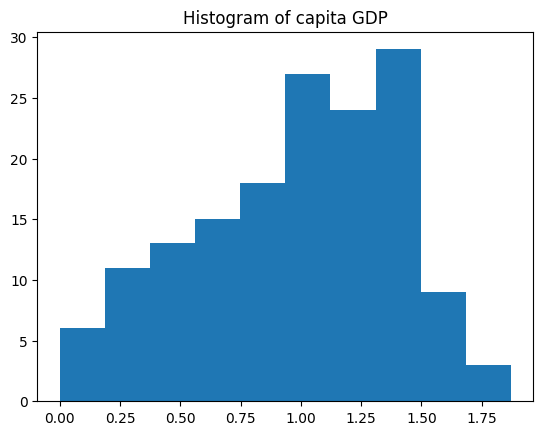

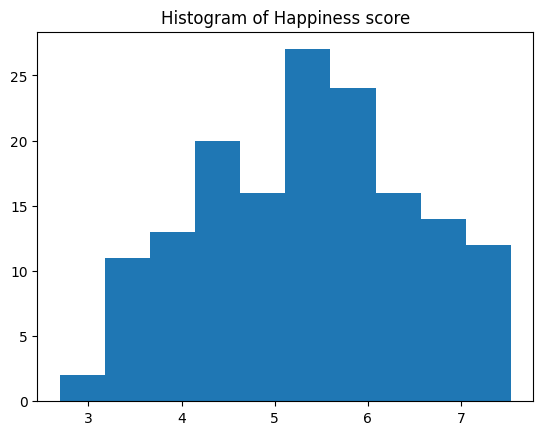

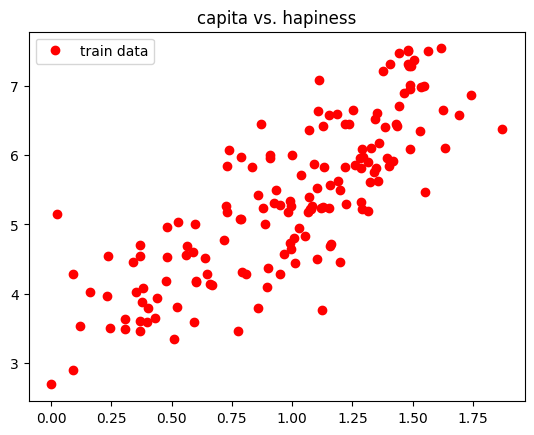

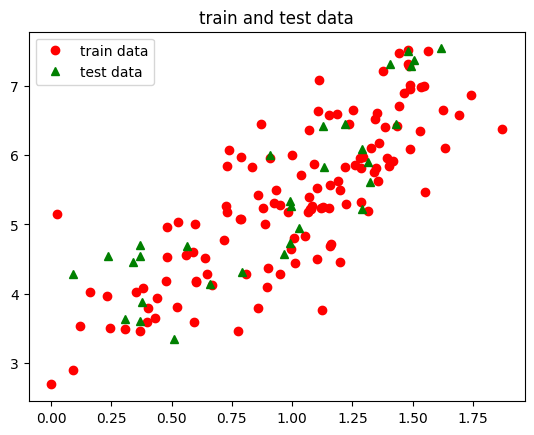

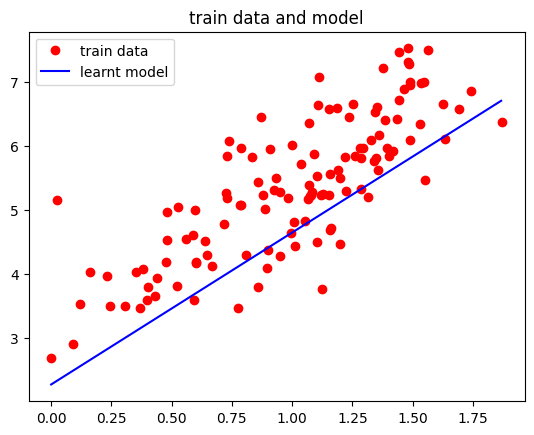

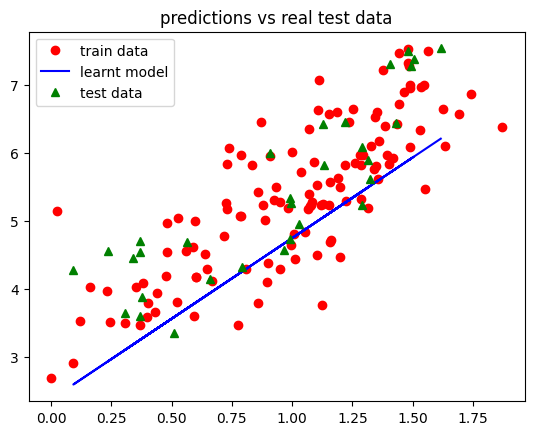

prediction error (manual):  1.0163663928857116
prediction error (tool):  1.0163663928857118
Learned model: f(x) = 2.2742654393007364 + [2.373185719350902] * x


In [ ]:
# model initialisation

# use sklearn regressor
from sklearn import linear_model
# regressor = linear_model.SGDRegressor(max_iter =  10000)

# using developed code - SGD Regression
# regressor = MySGDRegression()

# using developed code - BGD Regression
regressor = MyBGDRegression()

univariateRegression(regressor)
# extract the learned parameters
w0 = regressor.intercept_
w1 = regressor.coef_
print(f"Learned model: f(x) = {w0} + {w1} * x")

In [ ]:
# bivariate regression with batch gradient descent
def bivariateRegression(regressor):
    # load data for GDP and Freedom
    filePath = 'world-happiness-report-2017.csv'
    inputs, outputs = loadDataMoreInputs(filePath, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')

    # split data into train and test sets
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    testSample = [i for i in indexes if i not in trainSample]

    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]

    # normalize train and test data
    trainInputs, testInputs, means, std_devs = normalize_train_test(trainInputs, testInputs)

    # train the model
    regressor.fit(trainInputs, trainOutputs)

    # extract model parameters
    w0 = regressor.intercept_
    w1, w2 = regressor.coef_
    print(f"learned model: f(x) = {w0} + {w1} * x1 + {w2} * x2")

    # predict test data
    predictions = regressor.predict(testInputs)

    # visualize results in 3D
    feature1test = [ex[0] for ex in testInputs]
    feature2test = [ex[1] for ex in testInputs]
    plot3Ddata([], [], [], feature1test, feature2test, predictions, feature1test, feature2test, testOutputs, 'Predictions vs Real Test Data')

    # compute prediction error
    error = sklearn.metrics.mean_squared_error(testOutputs, predictions)
    print(f"prediction error: {error}")

In [ ]:
from sklearn.preprocessing import StandardScaler
from math import sqrt

def plot3Ddata(x1Train, x2Train, yTrain, x1Model=None, x2Model=None, yModel=None, x1Test=None, x2Test=None, yTest=None, title=None):
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    def safe_plot(x, y, z, color, marker, label):
        if x is not None and y is not None and z is not None and len(x) == len(y) == len(z) and len(x) > 0:
            ax.scatter(x, y, z, c=color, marker=marker, label=label)

    safe_plot(x1Train, x2Train, yTrain, 'r', 'o', 'train data')
    safe_plot(x1Model, x2Model, yModel, 'b', '_', 'learnt model')
    safe_plot(x1Test, x2Test, yTest, 'g', '^', 'test data')

    ax.set_title(title)
    ax.set_xlabel("capita")
    ax.set_ylabel("freedom")
    ax.set_zlabel("happiness")
    ax.legend()
    plt.show()


In [ ]:
def normalisation(trainData, testData):
    scaler = StandardScaler()
    if not isinstance(trainData[0], list):
        #encode each sample into a list
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]

        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data

        #decode from list to raw values
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data
    return normalisedTrainData, normalisedTestData

In [ ]:
def bivariateRegression(regressor):

  filePath = '/content/world-happiness-report-2017.csv'
  inputs, outputs = loadDataMoreInputs(filePath, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')

  feature1 = [ex[0] for ex in inputs]
  feature2 = [ex[1] for ex in inputs]

  # plot the data histograms
  plotDataHistogram(feature1, 'capita GDP')
  plotDataHistogram(feature2, 'freedom')
  plotDataHistogram(outputs, 'Happiness score')

  # check the liniarity (to check that a linear relationship exists between the dependent variable (y = happiness) and the independent variables (x1 = capita, x2 = freedom).)
  plot3Ddata(feature1, feature2, outputs, [], [], [], [], [], [], 'capita vs freedom vs happiness')


  np.random.seed(5)
  indexes = [i for i in range(len(inputs))]
  trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
  testSample = [i for i in indexes  if not i in trainSample]

  trainInputs = [inputs[i] for i in trainSample]
  trainOutputs = [outputs[i] for i in trainSample]
  testInputs = [inputs[i] for i in testSample]
  testOutputs = [outputs[i] for i in testSample]


  trainInputs, testInputs = normalisation(trainInputs, testInputs)
  trainOutputs, testOutputs = normalisation(trainOutputs, testOutputs)

  feature1train = [ex[0] for ex in trainInputs]
  feature2train = [ex[1] for ex in trainInputs]

  feature1test = [ex[0] for ex in testInputs]
  feature2test = [ex[1] for ex in testInputs]

  plot3Ddata(feature1train, feature2train, trainOutputs, [], [], [], feature1test, feature2test, testOutputs, "train and test data (after normalisation)")
  # identify (by training) the regressor

  regressor.fit(trainInputs, trainOutputs)
  # print(regressor.coef_)
  # print(regressor.intercept_)

  #parameters of the liniar regressor
  w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
  print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x1 + ', w2, ' * x2' )

  #numerical representation of the regressor model
  noOfPoints = 50
  xref1 = []
  val = min(feature1)
  step1 = (max(feature1) - min(feature1)) / noOfPoints
  for _ in range(1, noOfPoints):
      for _ in range(1, noOfPoints):
          xref1.append(val)
      val += step1

  xref2 = []
  val = min(feature2)
  step2 = (max(feature2) - min(feature2)) / noOfPoints
  for _ in range(1, noOfPoints):
      aux = val
      for _ in range(1, noOfPoints):
          xref2.append(aux)
          aux += step2
  yref = [w0 + w1 * el1 + w2 * el2 for el1, el2 in zip(xref1, xref2)]

  plot3Ddata(feature1train, feature2train, trainOutputs, xref1, xref2, yref, [], [], [], 'train data and the learnt model')

  # use the trained model to predict new inputs

  # makes predictions for test data
  # computedTestOutputs = [w0 + w1 * el[0] + w2 * el[1] for el in testInputs]
  # makes predictions for test data (by tool)
  computedTestOutputs = regressor.predict(testInputs)

  plot3Ddata([], [], [], feature1test, feature2test, computedTestOutputs, feature1test, feature2test, testOutputs, 'predictions vs real test data')

  #compute the differences between the predictions and real outputs
  error = 0.0
  for t1, t2 in zip(computedTestOutputs, testOutputs):
      error += (t1 - t2) ** 2
  error = error / len(testOutputs)
  print('prediction error (manual): ', error)

  from sklearn.metrics import mean_squared_error

  error = mean_squared_error(testOutputs, computedTestOutputs)
  print('prediction error (tool):   ', error)

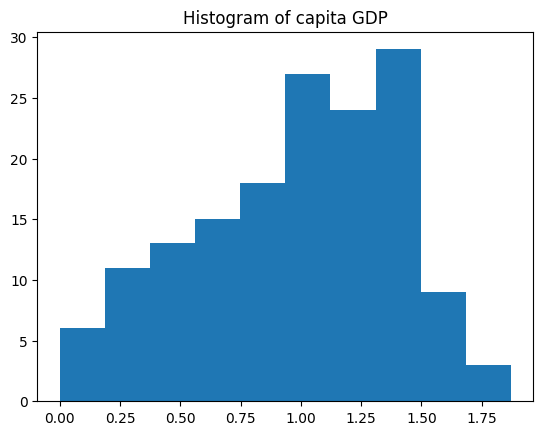

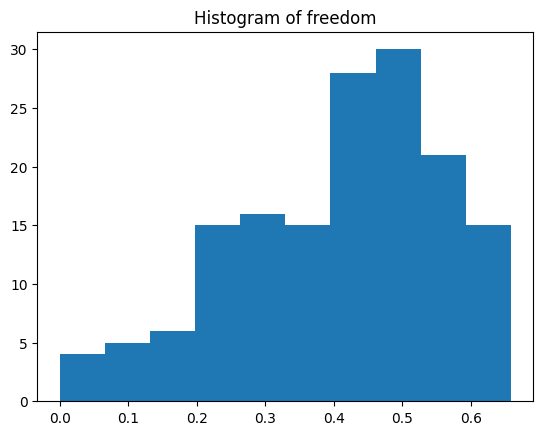

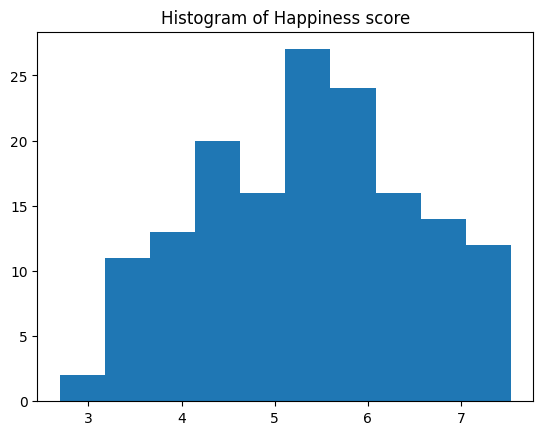

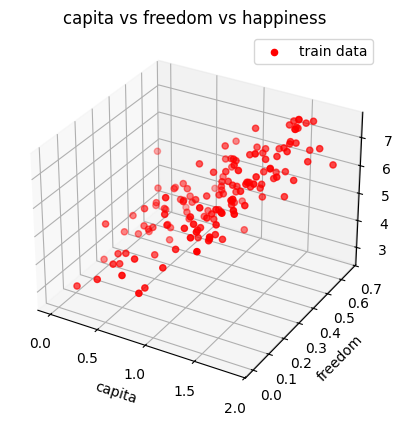

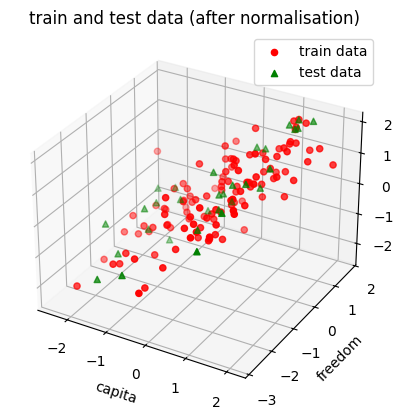

the learnt model: f(x) =  -4.884052391908709e-16  +  0.4649921407607235  * x1 +  0.27383646372932924  * x2


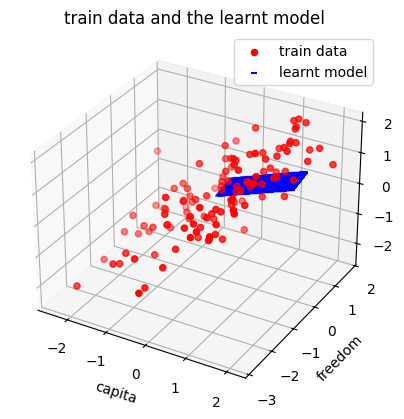

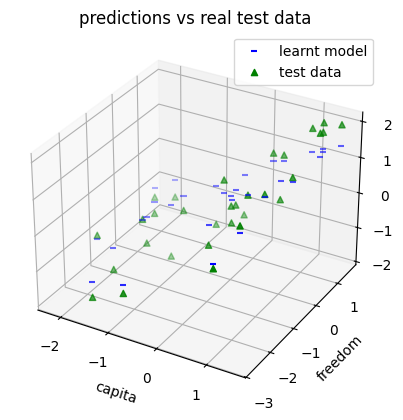

prediction error (manual):  0.3283735949333049
prediction error (tool):    0.3283735949333049


In [ ]:
# model initialisation

# use sklearn regressor

from sklearn import linear_model
#regressor = linear_model.SGDRegressor(max_iter =  10000)

# using developed code - SGD Regression
# regressor = MySGDRegression()

# using developed code - SGD Regression
regressor = MyBGDRegression()

bivariateRegression(regressor)

In [ ]:
from sklearn.linear_model import SGDRegressor
import numpy as np

# train model using sklearn
def train_with_sklearn(trainInputs, trainOutputs):
    # ensure inputs are 2D
    trainInputs = np.array(trainInputs)
    if trainInputs.ndim == 1:
        trainInputs = trainInputs.reshape(-1, 1)

    # initialize and train SGDRegressor
    regressor = SGDRegressor(max_iter=1000, tol=1e-3, learning_rate='constant', eta0=0.01)
    regressor.fit(trainInputs, trainOutputs)

    # extract model parameters
    w0 = regressor.intercept_[0]
    w1 = regressor.coef_[0]
    print(f"learned model with sklearn: f(x) = {w0} + {w1} * x")

    return regressor

learned model: f(x) = 5.3534946735514755 + 0.769648555742733 * x1 + 0.3363434033240974 * x2


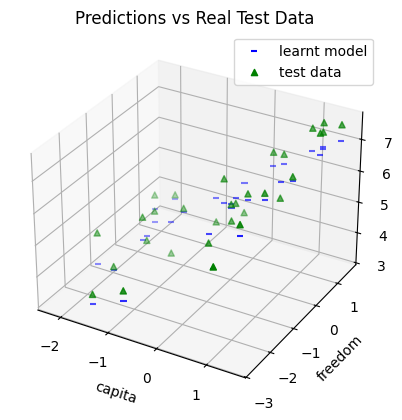

prediction error: 0.2778840169554103
learned model with sklearn: f(x) = 0.017821712182381343 + 0.7057271381664139 * x


In [ ]:
# Inițializare model
regressor = MyBGDRegression()

# Rulare regresie bivariată
bivariateRegression(regressor)

# Testare cu sklearn
regressor_sklearn = train_with_sklearn(trainInputs, trainOutputs)